# Optimising the MPM
The MPM algorithm was shown to be an accurate pitch detection algorithm [here](./1_mpm_direct.ipynb). However, this direct implementation is $O(n^2)$. There are several strategies to increase the efficiency.

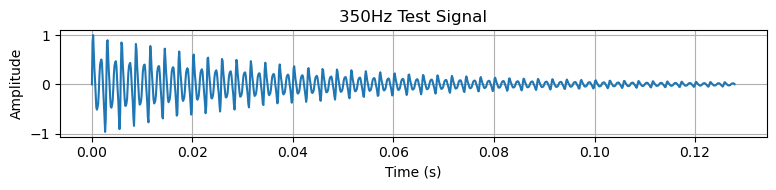

In [8]:
freq = 350
fs = 8e3
N = 1024
from utils import create_guitar_signal, plot_signal2, plot_signal

signal, time = create_guitar_signal(fs, freq, N, amplitude=1, decay_rate=25.0)

plot_signal(signal=signal, time=time, title=f"{freq}Hz Test Signal", figsize=(8, 2))

## 1. Optimise the ACF
There are two main approaches to optimise autocorrelation, with the best choice depending on signal length and available resources.
The direct time-domain method is $O(N²)$ while FFT-based computation is $O(N \log N)$. However, FFT requires $2N$ memory for zero-padding and has setup overhead, making the crossover point platform-dependent.
Since the STM32L4 I have chosen is limted on RAM I will use the dot product method.

$$r'(\tau) = \sum_{j=0}^{W-1-\tau} x_j\,x_{j+\tau}$$


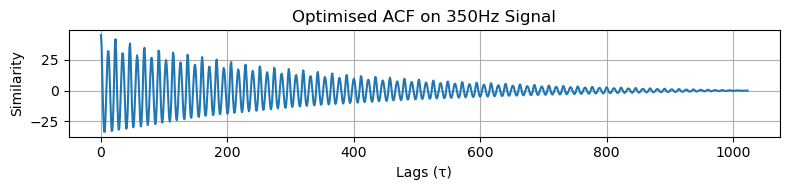

In [9]:
import numpy as np
def ACF_optimised(signal):
    
    signal = np.array(signal)
    W = len(signal)
    corr = np.zeros(W)

    for tau in range(W):
        a = signal[tau:W]
        b = signal[0: W - tau]
        corr[tau] = np.dot(a, b)

    return corr

acf = ACF_optimised(signal)
lags = range(len(acf))
plot_signal(
    signal=acf, 
    time=lags, 
    title=f"Optimised ACF on {freq}Hz Signal", 
    figsize=(8, 2),
    xlabel="Lags (τ)",
    ylabel="Similarity")

## 2. Optimise the SOSF
The SOSF formula as written is $O(N^2)$. This can be optimised to $O(N)$ using a sliding window approach that maintains rolling sums for both $x_j^2$ and $x_{j+\tau}^2$ terms.

$$m'(\tau)=\sum_{j = 0}^{W - 1 - \tau}\bigl(x_j^2 + x_{j+\tau}^2\bigr)$$

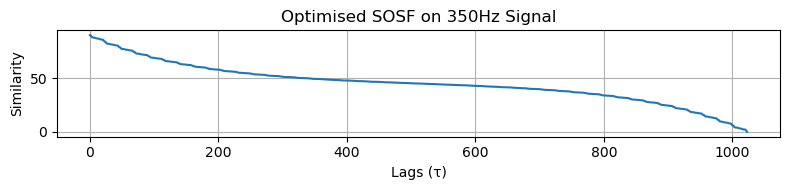

In [10]:

def SOSF_optimised(signal):
    W = len(signal)
    sosf = np.zeros(W)
    x_squared = np.array(signal) ** 2
    sum_xj_squared = np.sum(x_squared)      # Rolling sum of x_j^2 terms
    sum_xj_tau_squared = sum_xj_squared     # Rolling sum of x_{j+τ}^2 terms

    for tau in range(W):
        sosf[tau] = sum_xj_squared + sum_xj_tau_squared
        sum_xj_squared -= x_squared[tau]            
        sum_xj_tau_squared -= x_squared[W - tau - 1]  
    
    return sosf

sosf = SOSF_optimised(signal)

plot_signal(
    signal=sosf, 
    time=lags, 
    title=f"Optimised SOSF on {freq}Hz Signal", 
    figsize=(8, 2),
    xlabel="Lags (τ)",
    ylabel="Similarity")

## 3. Optimised NSDF
Now we have the ACF ($r$) and SOSF ($m$) we can put it together to get the NSDF.
$$n'_t(\tau) = \frac{2\,r'_t(\tau)}{m'_t(\tau)}$$

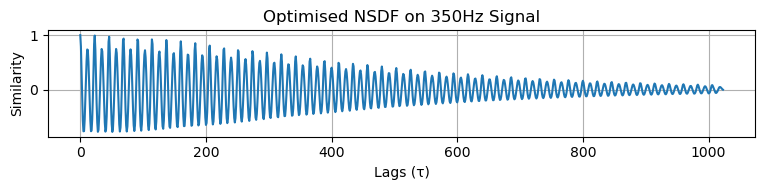

In [11]:
def NSDF_optimised(signal):

    W = len(signal)
    r = ACF_optimised(signal)
    n = np.zeros(W)

    x_squared = np.array(signal) ** 2
    sum_xj_squared = np.sum(x_squared)    
    sum_xj_tau_squared = sum_xj_squared   

    for tau in range(W):
        m = sum_xj_squared + sum_xj_tau_squared
        n[tau] = (2 * r[tau]) / m

        sum_xj_squared -= x_squared[tau]            
        sum_xj_tau_squared -= x_squared[W - tau - 1]  
    
    return n

nsdf = NSDF_optimised(signal)

plot_signal(
    signal=nsdf, 
    time=lags, 
    title=f"Optimised NSDF on {freq}Hz Signal", 
    figsize=(8, 2),
    xlabel="Lags (τ)",
    ylabel="Similarity")

# 4. Optimised Peak Picking
Peak picking is already $O(N)$ as it is a linear search. However, a small improvement can be made. Since the purpose of this pitch detection is for a guitar tuner, we know we don't care much about notes below the low E string (E2 $~82$ Hz). If we ignore all frequencies below $60$ Hz, then we can stop the peak search before reaching the end of the signal.
$$
\tau_{\text{stop}} = \frac{f_s}{f} = \frac{8000}{60} \approx 133
$$

In [12]:
def peak_picking_optimised(signal, threshold, stop_search=133):
    max_peak_val = 0
    max_peak_lag = 0
    zero_crossed = False
    
    for tau in range(stop_search):
        val = signal[tau]
        if not zero_crossed and val < 0:
            zero_crossed = True

        if zero_crossed and val > threshold and val > max_peak_val:
            max_peak_val = val
            max_peak_lag = tau
    return max_peak_lag

## NSDF Optimised
Putting all the optimised pieces together.

In [13]:
from utils import parabolic_interpolation

def MPM_optimised(signal):
    nsdf = NSDF_optimised(signal)
    tau = peak_picking_optimised(nsdf, 0.8)
    if tau == 0:
        return 0
    a = nsdf[tau - 1]
    b = nsdf[tau]
    c = nsdf[tau + 1]
    delta_tau = parabolic_interpolation(tau, a, b, c)
    f = fs / delta_tau
    return f


pitch = MPM_optimised(signal)
print(f"{pitch:.3f} Hz")

349.982 Hz


## Performance Comparison

In [14]:
from utils import compare_execution_times, NSDF_direct

compare_execution_times(NSDF_direct, NSDF_optimised, signal)



NSDF_direct average time: 0.092813 seconds
NSDF_optimised average time: 0.000699 seconds
Speedup: 132.82x


(np.float64(0.0928126335144043), np.float64(0.0006988048553466797))